## Audio Recordings 5 Languages

I have recorded a few phrases in 5 languages.  


##### English, Hindi, Kannada, Marathi, and Telugu.  

The phrases were:  

"Today is a sunny day and the weather is very nice. I am drinking a cup of tea.  
My favourite numbers are one, two, three, four, five, six, seven."  



I recorded them on my phone and converted them to .wav files on the WSL.  

Then I converted them from 48kHz to 16kHz. We will be using 16kHz frequency for speech related audios.  

The files are stored inside a folder, in the main data folder.  

Towards the end, I have also created a seperate 'plots' folder, inside the data folder. This folder shows the waveform and mel spectrogram of the different audio clips I had recoeded. 


### English Audio Testing, Loading


In [1]:
# --- Cell 1: Imports + load a single audio file ---

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Path to our audio folder (relative to where the notebook lives)
AUDIO_DIR = Path("data/audio_clips")

# Load one file — let's start with english
file_path = AUDIO_DIR / "english.wav"

# librosa.load returns two things:
#   y  = the audio as a NumPy array (the "long list of numbers")
#   sr = the sample rate (samples per second)
y, sr = librosa.load(file_path, sr=None)   # sr=None means: don't resample, keep original

# Quick sanity check
print(f"File loaded: {file_path}")
print(f"Sample rate (sr): {sr} Hz")
print(f"Audio shape: {y.shape}")
print(f"Duration: {len(y) / sr:.2f} seconds")
print(f"Data type: {y.dtype}")
print(f"Min value: {y.min():.4f}, Max value: {y.max():.4f}")

File loaded: data/audio_clips/english.wav
Sample rate (sr): 16000 Hz
Audio shape: (221184,)
Duration: 13.82 seconds
Data type: float32
Min value: -0.6831, Max value: 0.7014


### Creating the Waveform

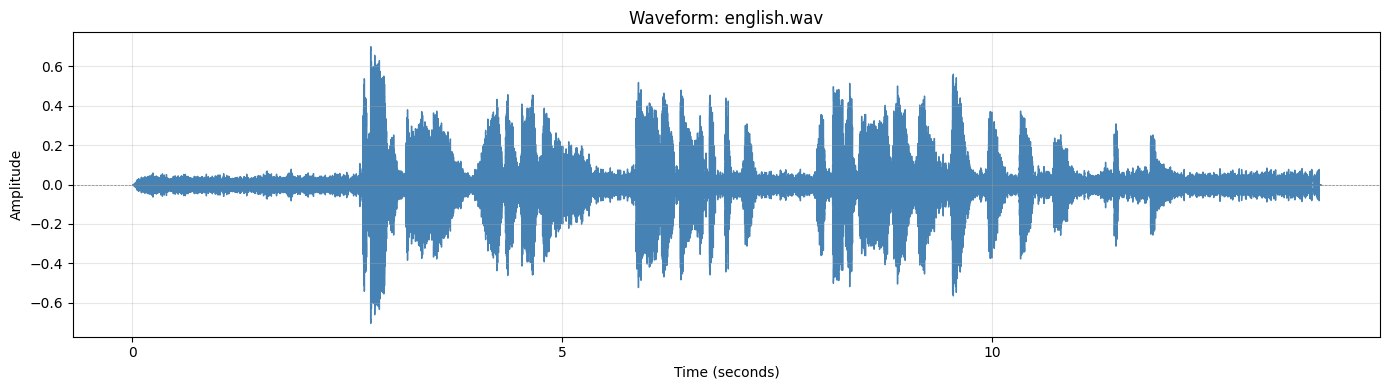

In [2]:
# --- Cell 2: Plot the waveform ---

# Create a figure (a blank canvas to draw on)
plt.figure(figsize=(14, 4))   # width=14 inches, height=4 inches

# librosa's waveshow handles the time axis for us automatically
librosa.display.waveshow(y, sr=sr, color="steelblue")

# Labels
plt.title("Waveform: english.wav")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

# A horizontal line at y=0 so silence is easy to spot
plt.axhline(0, color="gray", linewidth=0.5, linestyle="--")

# Grid makes it easier to read off time values
plt.grid(True, alpha=0.3)

plt.tight_layout()   # prevents labels from being cut off
plt.show()

### Differentiating the Silence vs Speech parts

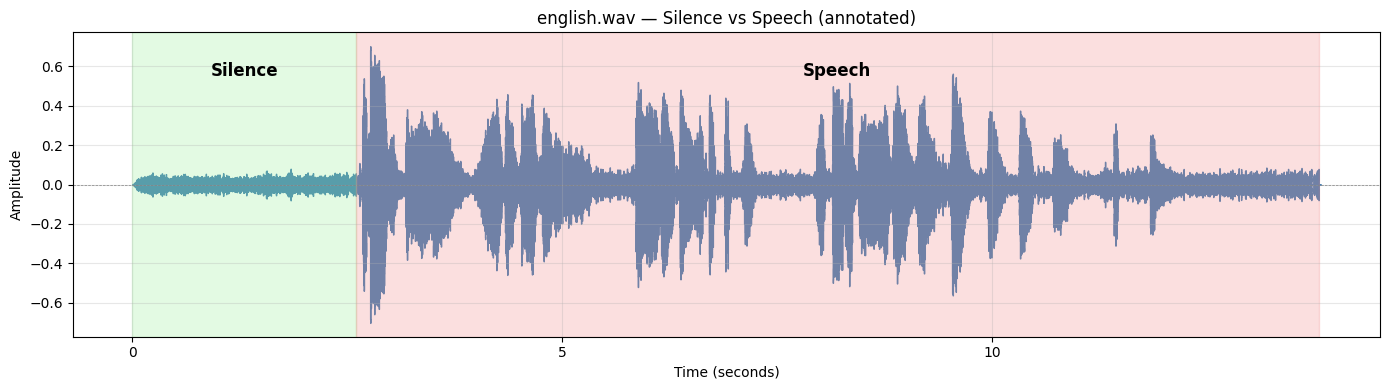

In [3]:
# --- Cell 3: Annotated waveform (silence vs speech) ---

plt.figure(figsize=(14, 4))
librosa.display.waveshow(y, sr=sr, color="steelblue")

# Define regions based on your eyeballing of the plot
# Each tuple: (start_sec, end_sec, label, color)
regions = [
    (0.0,  2.6,  "Silence",  "lightgreen"),
    (2.6,  13.8, "Speech",   "lightcoral"),
]

# Shade each region
for start, end, label, color in regions:
    plt.axvspan(start, end, alpha=0.25, color=color)
    # Put the text label in the middle of the region, near the top
    plt.text(
        (start + end) / 2,    # x-position: middle of the region
        0.55,                 # y-position: high up on the plot
        label,
        ha="center",          # horizontally center the text
        fontsize=12,
        fontweight="bold",
    )

plt.title("english.wav — Silence vs Speech (annotated)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.axhline(0, color="gray", linewidth=0.5, linestyle="--")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Plotting Mel Spectrogram

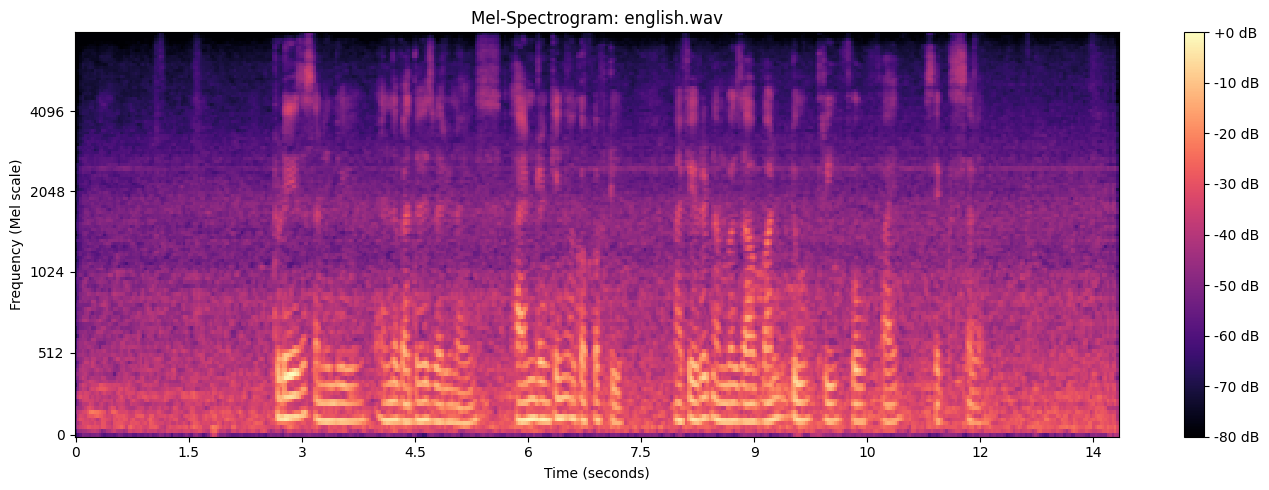

Mel-spectrogram shape: (128, 433)
  → 128 mel bands × 433 time frames


In [4]:
# --- Cell 4: Compute and plot the mel-spectrogram ---

# Step 1: Compute the mel-spectrogram (raw "power" values)
mel_spec = librosa.feature.melspectrogram(
    y=y,            # the audio
    sr=sr,          # sample rate
    n_mels=128,     # number of mel bands (frequency bins on the y-axis)
)

# Step 2: Convert to decibels (log scale) so we can see detail
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

# Step 3: Plot it as a heatmap
plt.figure(figsize=(14, 5))
img = librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    x_axis="time",   # label x-axis in seconds
    y_axis="mel",    # label y-axis in mel scale
    cmap="magma",    # color scheme — try "viridis" or "inferno" too
)

# Add a colorbar so we know what the colors mean
plt.colorbar(img, format="%+2.0f dB")

plt.title("Mel-Spectrogram: english.wav")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Mel scale)")
plt.tight_layout()
plt.show()

# Quick sanity check on shape
print(f"Mel-spectrogram shape: {mel_spec_db.shape}")
print(f"  → {mel_spec_db.shape[0]} mel bands × {mel_spec_db.shape[1]} time frames")

#### Why the scale is from -80dB to +0dB

The values on the mel scale can range a lot. Like it can be from 0.0001 to 1000000. Its very hard to represent that on a scale with the color.  

So we take log of the number.  

After some calculations and formulas, 0dB will represent the loudest sound in the clip.  

-10dB means that its 10x quieter  
-20dB is 100x quieter  
-30dB is 1000x quieter and so on  


### Side by Side Mel Spectrogram and Waveform

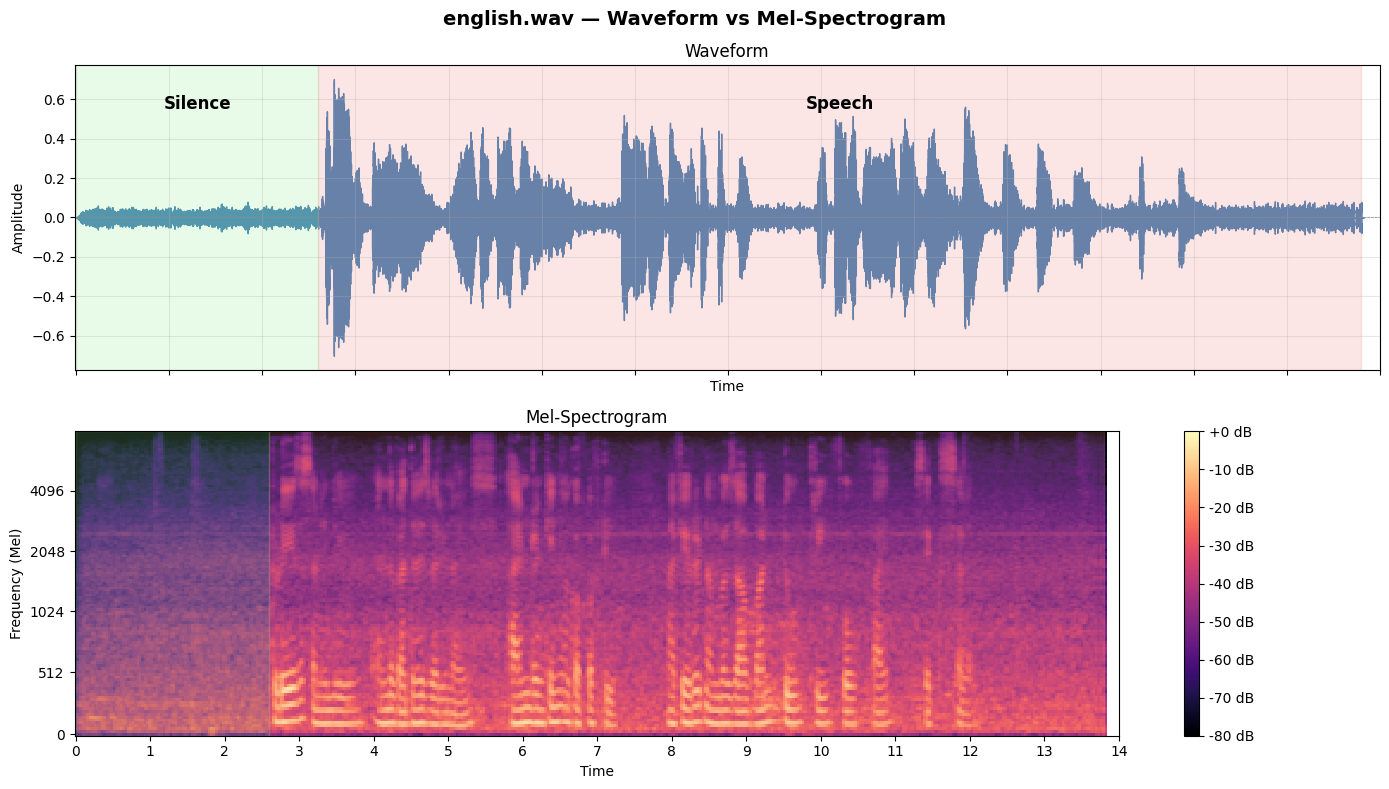

In [5]:
# --- Cell 5: Side-by-side waveform + mel-spectrogram with annotations ---

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 8))

# ---------- TOP PANEL: Waveform ----------
librosa.display.waveshow(y, sr=sr, color="steelblue", ax=axes[0])
axes[0].set_title("Waveform")
axes[0].set_ylabel("Amplitude")
axes[0].axhline(0, color="gray", linewidth=0.5, linestyle="--")
axes[0].grid(True, alpha=0.3)

# ---------- BOTTOM PANEL: Mel-spectrogram ----------
img = librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    x_axis="time",
    y_axis="mel",
    cmap="magma",
    ax=axes[1],
)
axes[1].set_title("Mel-Spectrogram")
axes[1].set_ylabel("Frequency (Mel)")

# Colorbar attached to the spectrogram panel only
fig.colorbar(img, ax=axes[1], format="%+2.0f dB")

# ---------- ANNOTATIONS: silence vs speech regions ----------
regions = [
    (0.0,  2.6,  "Silence", "lightgreen"),
    (2.6,  13.8, "Speech",  "lightcoral"),
]

for start, end, label, color in regions:
    # Shade BOTH panels — same time region on each
    for ax in axes:
        ax.axvspan(start, end, alpha=0.2, color=color)
    # Label only on the top panel so it doesn't crowd the spectrogram
    axes[0].text(
        (start + end) / 2,
        0.55,
        label,
        ha="center",
        fontsize=12,
        fontweight="bold",
    )

# Overall title for the whole figure
fig.suptitle("english.wav — Waveform vs Mel-Spectrogram", fontsize=14, fontweight="bold")

import numpy as np

# Force ticks every 1 second from 0 to end of audio
duration = len(y) / sr   # total seconds of the audio
axes[1].set_xticks(np.arange(0, duration + 1, 1))   # every 1 sec

plt.tight_layout()
plt.show()

### Deeper check on Silence vs Speech

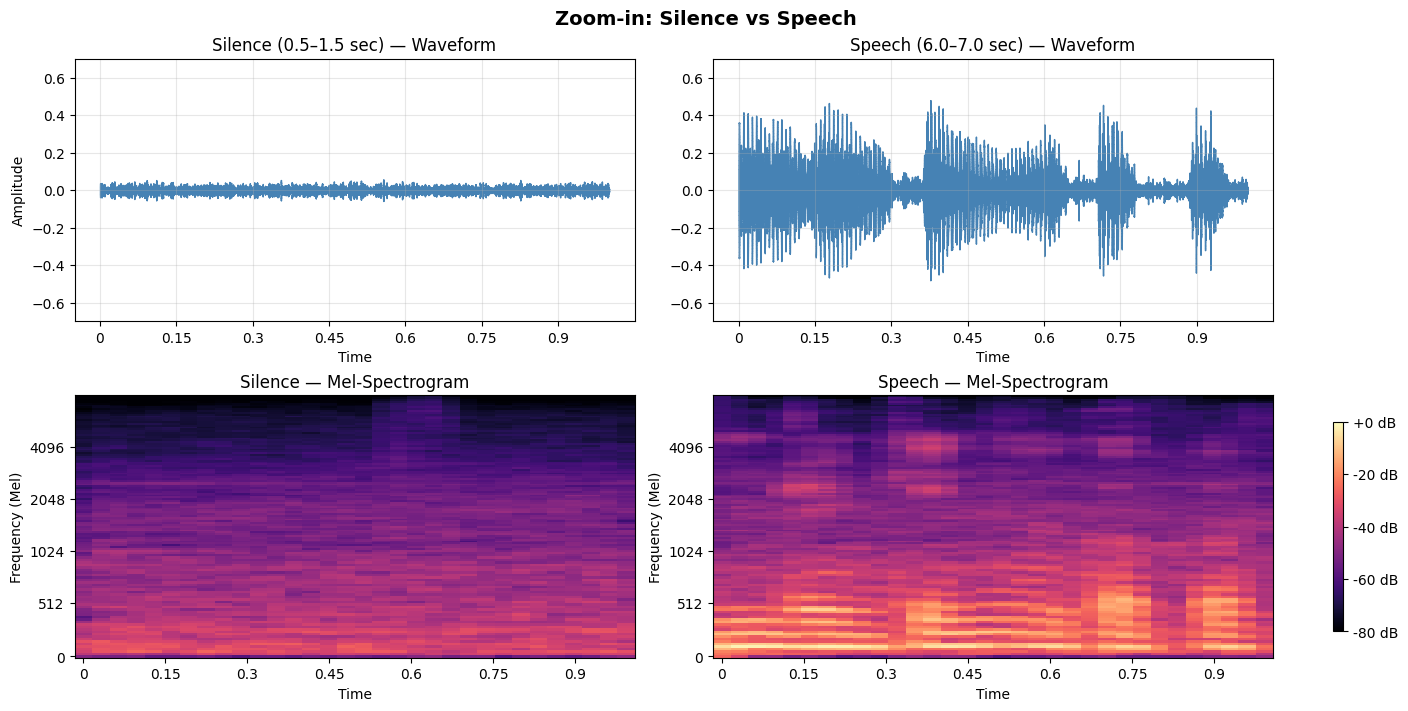

In [6]:
# --- Cell 6: Zoom-in on silence vs speech ---

# Pick zoom windows (in seconds)
silence_start, silence_end = 0.5, 1.5   # 1 sec of pure silence
speech_start,  speech_end  = 6.0, 7.0   # 1 sec of clear speech

# Convert seconds → sample indices
sil_idx = (int(silence_start * sr), int(silence_end * sr))
spc_idx = (int(speech_start  * sr), int(speech_end  * sr))

# Slice the audio
y_silence = y[sil_idx[0]:sil_idx[1]]
y_speech  = y[spc_idx[0]:spc_idx[1]]

# Compute raw mel-spectrograms for each slice
mel_sil_raw = librosa.feature.melspectrogram(y=y_silence, sr=sr, n_mels=128)
mel_spc_raw = librosa.feature.melspectrogram(y=y_speech,  sr=sr, n_mels=128)

# IMPORTANT: use the FULL audio's peak as the dB reference, so colors are comparable
shared_ref = np.max(mel_spec)   # mel_spec is from Cell 4, the full audio's raw mel

mel_sil_db = librosa.power_to_db(mel_sil_raw, ref=shared_ref)
mel_spc_db = librosa.power_to_db(mel_spc_raw, ref=shared_ref)

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 7), constrained_layout=True)

# ---------- Top-left: Silence waveform ----------
librosa.display.waveshow(y_silence, sr=sr, color="steelblue", ax=axes[0, 0])
axes[0, 0].set_title("Silence (0.5–1.5 sec) — Waveform")
axes[0, 0].set_ylim(-0.7, 0.7)        # match the speech panel for fair visual comparison
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].grid(True, alpha=0.3)

# ---------- Top-right: Speech waveform ----------
librosa.display.waveshow(y_speech, sr=sr, color="steelblue", ax=axes[0, 1])
axes[0, 1].set_title("Speech (6.0–7.0 sec) — Waveform")
axes[0, 1].set_ylim(-0.7, 0.7)
axes[0, 1].grid(True, alpha=0.3)

# ---------- Bottom-left: Silence mel-spectrogram ----------
img1 = librosa.display.specshow(
    mel_sil_db, sr=sr, x_axis="time", y_axis="mel",
    cmap="magma", ax=axes[1, 0], vmin=-80, vmax=0,   # lock color range
)
axes[1, 0].set_title("Silence — Mel-Spectrogram")
axes[1, 0].set_ylabel("Frequency (Mel)")

# ---------- Bottom-right: Speech mel-spectrogram ----------
img2 = librosa.display.specshow(
    mel_spc_db, sr=sr, x_axis="time", y_axis="mel",
    cmap="magma", ax=axes[1, 1], vmin=-80, vmax=0,   # same color range
)
axes[1, 1].set_title("Speech — Mel-Spectrogram")
axes[1, 1].set_ylabel("Frequency (Mel)")

# One shared colorbar on the right
fig.colorbar(img2, ax=axes[1, :], format="%+2.0f dB", shrink=0.8)

fig.suptitle("Zoom-in: Silence vs Speech", fontsize=14, fontweight="bold")
plt.show()

## Plotting for All 5 Languages

Saved: data/plots/english_waveform_melspec.png


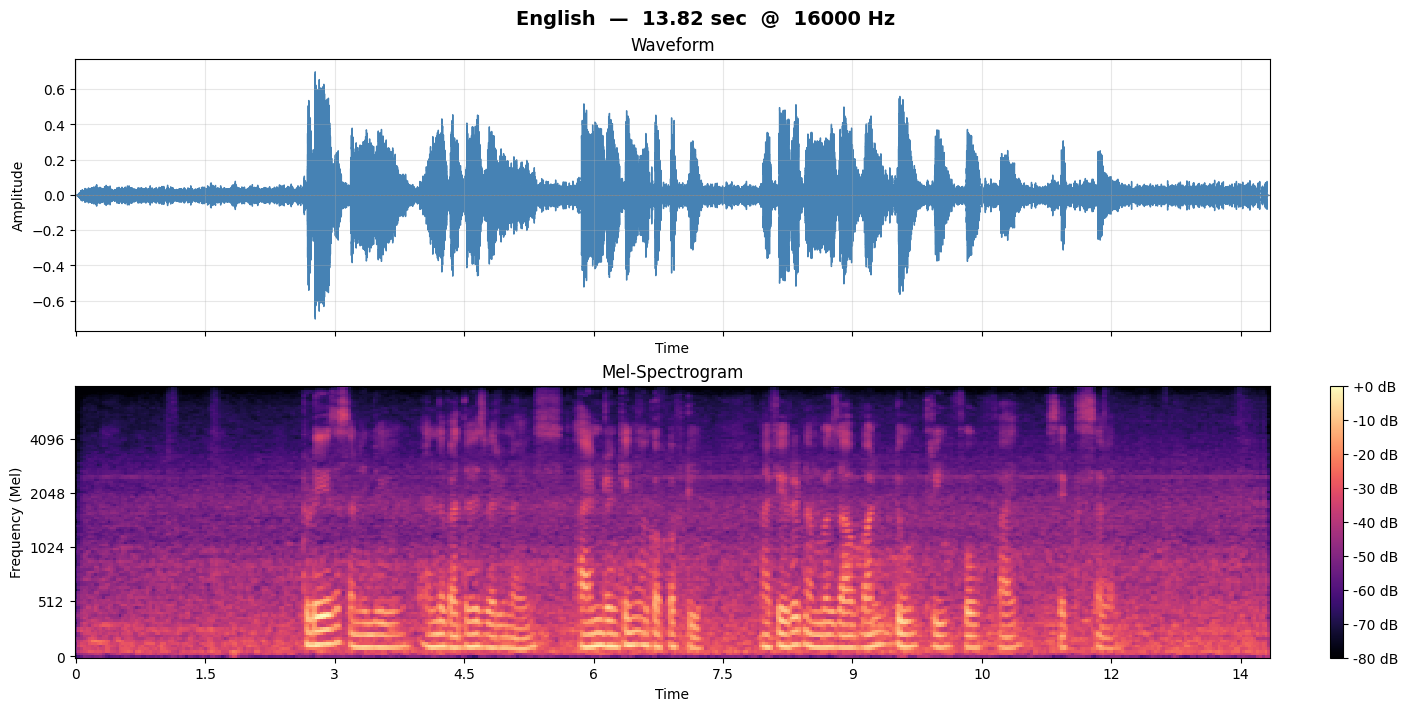

Saved: data/plots/hindi_waveform_melspec.png


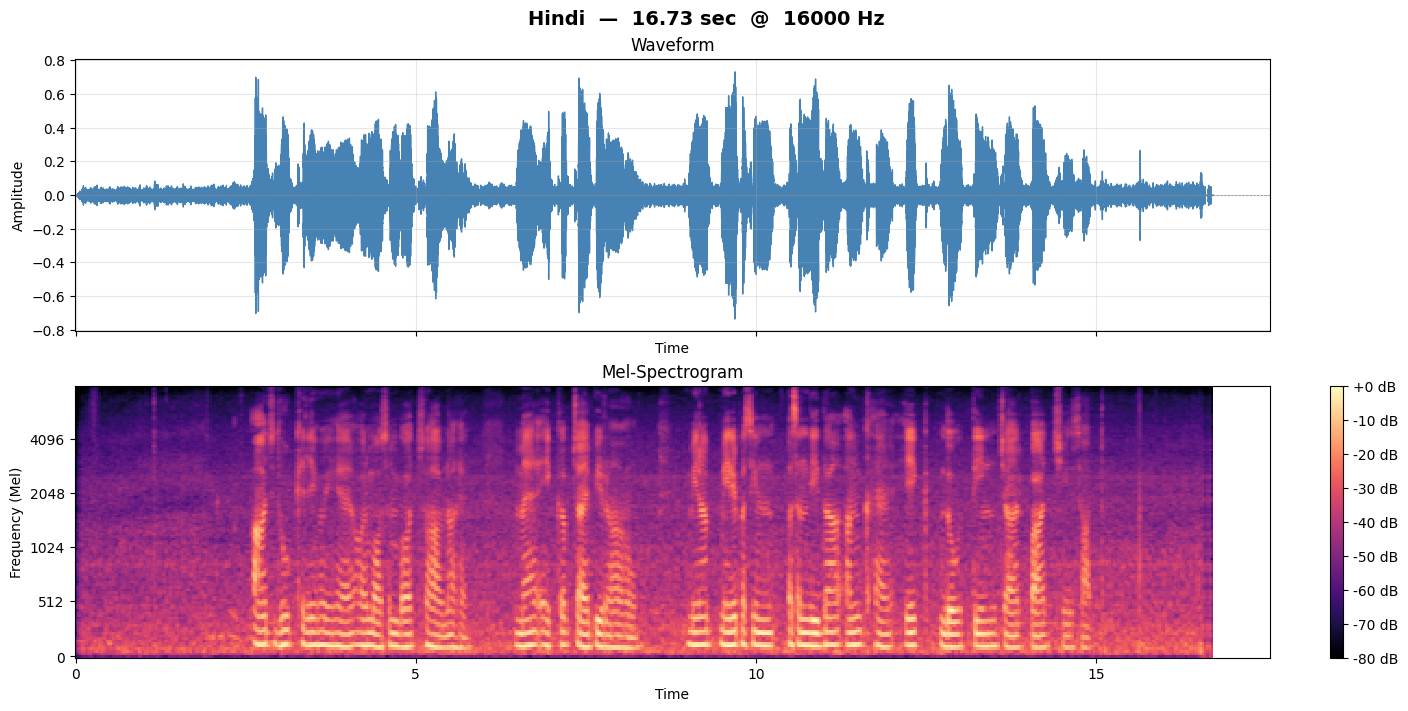

Saved: data/plots/marathi_waveform_melspec.png


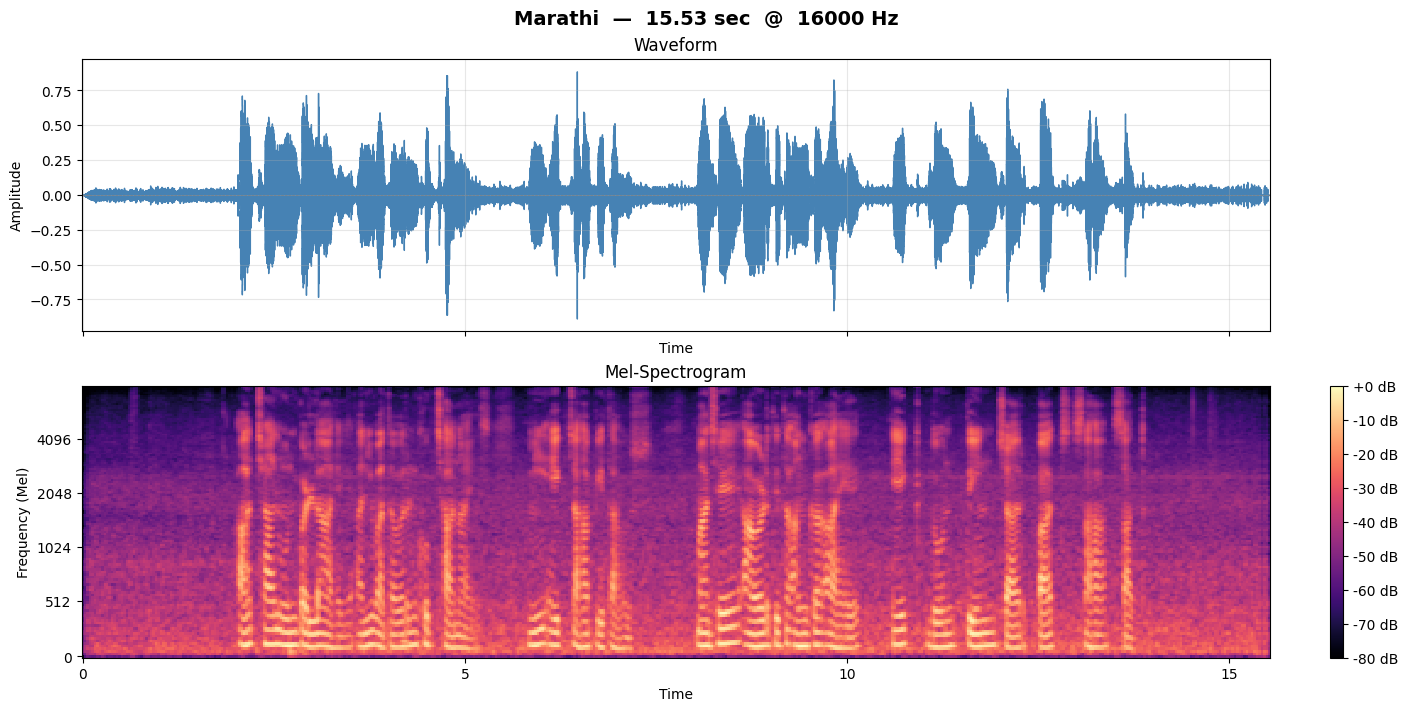

Saved: data/plots/kannada_waveform_melspec.png


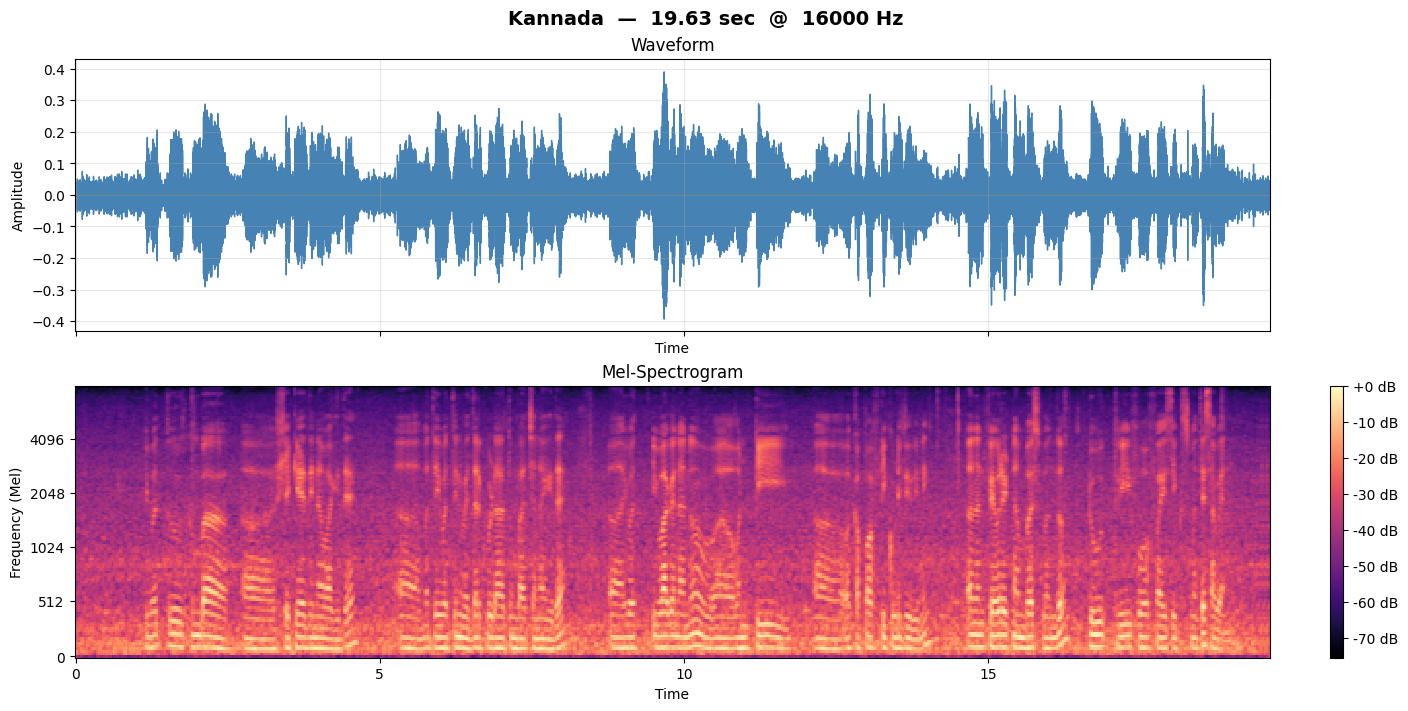

Saved: data/plots/telugu_waveform_melspec.png


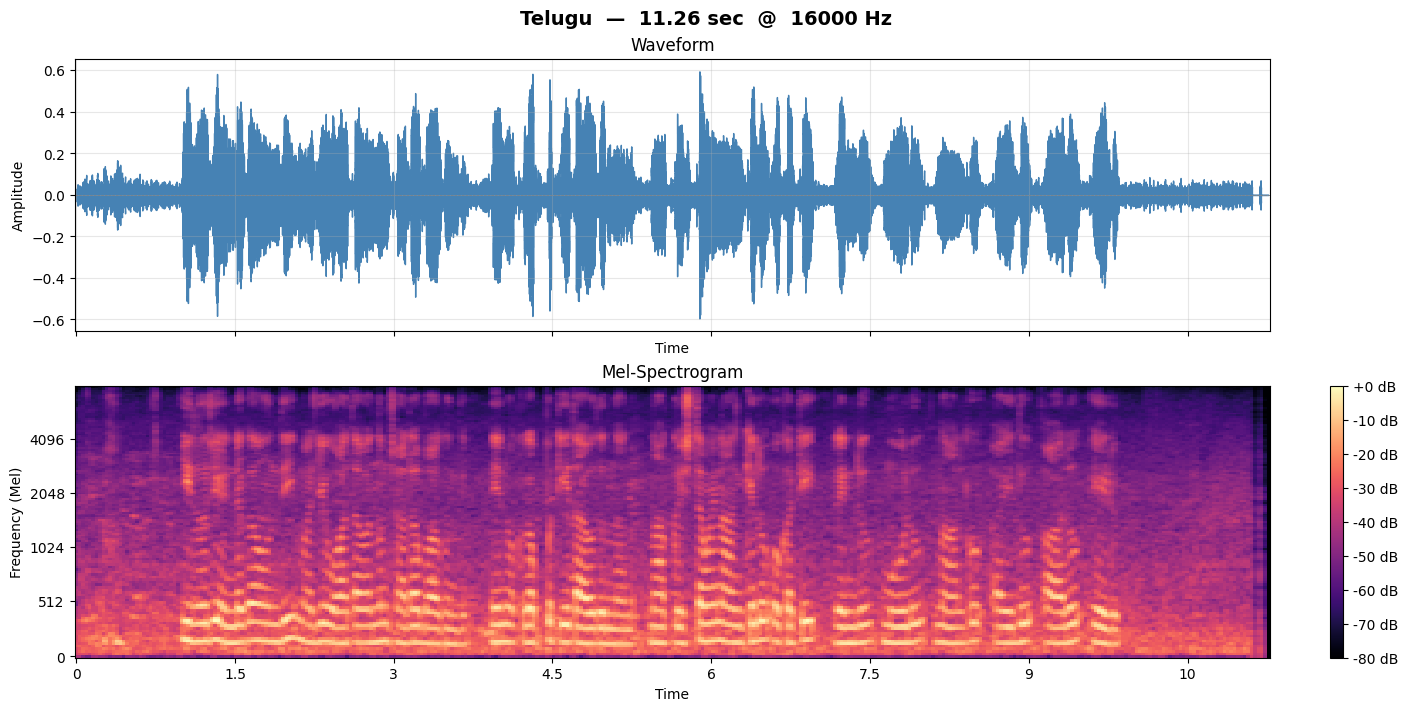


All 5 plots saved to data/plots/


In [7]:
# --- Cell 7: Loop through all 5 languages, save plots ---

# Make sure the plots folder exists
PLOTS_DIR = Path("data/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# The 5 files to process
languages = ["english", "hindi", "marathi", "kannada", "telugu"]

for lang in languages:
    file_path = AUDIO_DIR / f"{lang}.wav"
    
    # ---------- 1. Load ----------
    y_lang, sr_lang = librosa.load(file_path, sr=None)
    duration = len(y_lang) / sr_lang
    
    # ---------- 2. Compute mel-spectrogram (in dB) ----------
    mel = librosa.feature.melspectrogram(y=y_lang, sr=sr_lang, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    # ---------- 3. Build the side-by-side plot ----------
    fig, axes = plt.subplots(
        2, 1, sharex=True, figsize=(14, 7), constrained_layout=True
    )
    
    # Top: waveform
    librosa.display.waveshow(y_lang, sr=sr_lang, color="steelblue", ax=axes[0])
    axes[0].set_title("Waveform")
    axes[0].set_ylabel("Amplitude")
    axes[0].axhline(0, color="gray", linewidth=0.5, linestyle="--")
    axes[0].grid(True, alpha=0.3)
    
    # Bottom: mel-spectrogram
    img = librosa.display.specshow(
        mel_db, sr=sr_lang, x_axis="time", y_axis="mel",
        cmap="magma", ax=axes[1],
    )
    axes[1].set_title("Mel-Spectrogram")
    axes[1].set_ylabel("Frequency (Mel)")
    fig.colorbar(img, ax=axes[1], format="%+2.0f dB")
    
    # Overall title
    fig.suptitle(
        f"{lang.title()}  —  {duration:.2f} sec  @  {sr_lang} Hz",
        fontsize=14, fontweight="bold",
    )
    
    # ---------- 4. Save the figure ----------
    out_path = PLOTS_DIR / f"{lang}_waveform_melspec.png"
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    print(f"Saved: {out_path}")
    
    # ---------- 5. Show inline, then close to free memory ----------
    plt.show()
    plt.close(fig)

print("\nAll 5 plots saved to data/plots/")